# Clustering mobile user movements

Modern cell phones have powerful in-build sensors that allow tracking the physical movements of its user. From the data delivered by the accelerometer we can try to infer the underlying activity, such as walking or standing. Many useful applications can use this information, for instance fitness tracking or adaptive notifications.

In this exercise the task is to infer underlying movements of the user by grouping similar movement using unsupervised techniques. Apart from a small subset, the training samples are not labeled. In the end you may test if your groups correspond to the held out ground-truth activities. 

This task has two key challenges. **Extracting useful features** that are useful for classifying the activities, and implementing **effective clustering methods**. The task has these broad steps:
1. Load and visualize data
3. Extract features
3. Clustering methods
4. Validate clusters

Feel free to optimize your methods in each step and use all you have learned to improve your performance. Also feel free to reorganize your pipeline to make running the all steps at once easier, for instance with `sklearn.pipeline`.

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

### Load the data

#### About the data

The experiments have been carried out with a group of volunteers performing six activities (WALKING, WALKINGUPSTAIRS, WALKINGDOWNSTAIRS, SITTING, STANDING, LAYING) wearing a smartphone on the waist ([video](https://www.youtube.com/watch?v=XOEN9W05_4A)). Using its embedded accelerometer and gyroscope, 3-axial linear acceleration, body acceleration and angular velocity were collected.

For more info, the reference paper: [Domain Dataset for Human Activity Recognition Using Smartphones](https://scholar.google.com/scholar?q=a+public+domain+dataset+for+human+activity+recognition+using+smartphones&hl=en&as_sdt=0&as_vis=1&oi=scholart).


#### Import the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from scipy.stats import median_abs_deviation

#### Import the data files

Each data file has an array of times series, with X, Y and Z directions each.

In [2]:
body_acc_x_train = np.loadtxt("data/body_acc_x_train.txt")
body_acc_y_train = np.loadtxt("data/body_acc_y_train.txt")
body_acc_z_train = np.loadtxt("data/body_acc_z_train.txt")

body_gyro_x_train = np.loadtxt("data/body_gyro_x_train.txt")
body_gyro_y_train = np.loadtxt("data/body_gyro_y_train.txt")
body_gyro_z_train = np.loadtxt("data/body_gyro_z_train.txt")

total_acc_x_train = np.loadtxt("data/total_acc_x_train.txt")
total_acc_y_train = np.loadtxt("data/total_acc_y_train.txt")
total_acc_z_train = np.loadtxt("data/total_acc_z_train.txt")

print(body_acc_x_train.shape)

(7352, 128)


#### We can join the time series into a single raw dataset.

In [3]:
X_train = np.array(np.hstack([body_acc_x_train, body_acc_y_train, body_acc_z_train, 
                   body_gyro_x_train, body_gyro_y_train, body_gyro_z_train,
                   total_acc_x_train, total_acc_y_train, total_acc_z_train]))

print(X_train.shape)

(7352, 1152)


#### Load the labels for the first 200 samples of the data. 

The labels indicate:
1. WALKING
2. WALKING_UPSTAIRS
3. WALKING_DOWNSTAIRS
4. SITTING
5. STANDING
6. LAYING

In [4]:
y_train = np.loadtxt("data/y_train.txt")

Print the the number of samples in each category. Is the data set balanced?

In [5]:
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Activity {int(u)}: {c} samples")
print("The dataset is reasonably balanced.")

Activity 1: 36 samples
Activity 2: 28 samples
Activity 3: 30 samples
Activity 4: 31 samples
Activity 5: 44 samples
Activity 6: 31 samples
The dataset is reasonably balanced.


#### Visualize the trajectories

Inspect the time series data by plotting some (X,Y,Z) data samples over time.

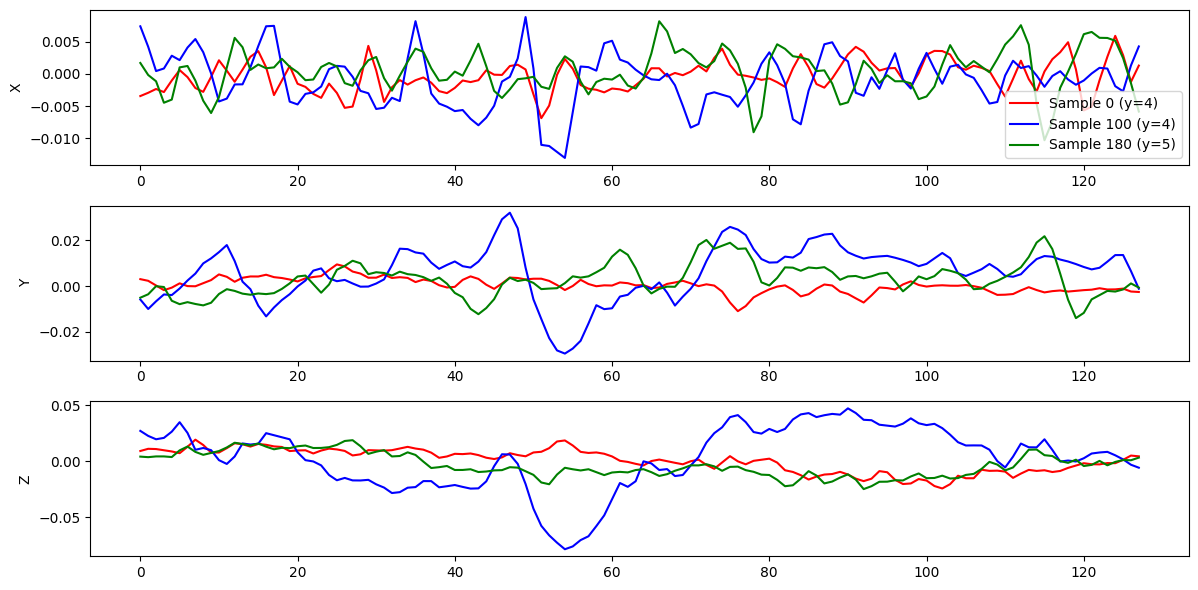

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for i, (label, color) in enumerate([(0, 'r'), (100, 'b'), (180, 'g')]):
    axes[0].plot(body_acc_x_train[label], color=color, label=f'Sample {label} (y={int(y_train[label]) if label < 200 else "?"})')
    axes[1].plot(body_acc_y_train[label], color=color)
    axes[2].plot(body_acc_z_train[label], color=color)
axes[0].set_ylabel('X'); axes[1].set_ylabel('Y'); axes[2].set_ylabel('Z')
axes[0].legend()
plt.tight_layout()
plt.show()

## Extract features

The raw time-series could be used directly as input to machine learning, but it might not be very effective. A key challenge is to extract features that could help identify and differentiate between activities. Feel free to select from or go beyond the suggestions and come up with your own features.

### Time series properties

* **Magnitude**: Calculate the magnitude of a 3-dimensional time series at each time point, given by the norm of the (X,Y,Z) vector: $$mag(t) = \sqrt{acc_X^2(t) + acc_Y^2(t) + acc_Z^2(t)}$$

* **Jerk**: Calculate the change in acceleration, known as jerk. You may calculate it by the different in acceleration over a time lag: $$jerk(t) = acc(t) - acc(t-lag)$$.

* **Spectral properties**: Calculate the frequency domain analysis using FFT of a time-series.

* **Autoregressive model**: Calculate the auto-regressive model for a time-series and use its parameters as features.

In [7]:
body_acc_magnitude = np.sqrt(body_acc_x_train**2 + body_acc_y_train**2 + body_acc_z_train**2)


In [9]:
# Jerk (difference) for body acceleration
body_jerk_x = np.diff(body_acc_x_train, axis=1)
body_jerk_y = np.diff(body_acc_y_train, axis=1)
body_jerk_z = np.diff(body_acc_z_train, axis=1)
body_jerk_magnitude = np.sqrt(body_jerk_x**2 + body_jerk_y**2 + body_jerk_z**2)

In [10]:
# Gyro magnitude
body_gyro_magnitude = np.sqrt(body_gyro_x_train**2 + body_gyro_y_train**2 + body_gyro_z_train**2)

In [11]:
# Total acc magnitude
total_acc_magnitude = np.sqrt(total_acc_x_train**2 + total_acc_y_train**2 + total_acc_z_train**2)

In [12]:
# FFT energy feature
def fft_energy(ts):
    fft_vals = np.fft.rfft(ts, axis=1)
    return np.sum(np.abs(fft_vals)**2, axis=1)

#### Join time series

In [13]:
allt = [body_acc_x_train, body_acc_y_train, body_acc_z_train, body_gyro_x_train, body_gyro_y_train,
       body_gyro_z_train, total_acc_x_train, total_acc_y_train, total_acc_z_train,
       body_acc_magnitude]


### Statistical features

* Design statistical features to extract from the time-series you have gathered, such as minimal/maximal value or standard deviation. Again, you can be creative on features that might be relevant to classify a time series, for instance the Median Absolute Deviation or the Signal Magnitude Area.

In [14]:
funcs = [np.min, np.std]


* Implement a function that estimate these statistical features for each time series and join them into a training dataset.

In [15]:
def extract_features(time_series_list, stat_funcs):
    features = []
    for ts in time_series_list:
        for func in stat_funcs:
            features.append(func(ts, axis=1).reshape(-1, 1))
    # Add FFT energy for each time series
    for ts in time_series_list:
        features.append(fft_energy(ts).reshape(-1, 1))
    return np.hstack(features)

X_features = extract_features(allt, funcs)

How many features do you have in total?

In [16]:
print(f"Total features: {X_features.shape[1]}")

Total features: 30


## Clustering activities

Now that you have defined your features, the second key challenge is to model your data with clustering algorithms, trying to group data sample of the same activity together.

### Preprocess features

Make sure to preprocess your data to be adequate as input to your algorithms.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

## Clustering

* Now is the time to implement the core clustering algorithm with the data you have preprocessed.
* You can use any algorithm you have learned. Remember to optimize its parameters for performance.
* Note that you can use the few available labels to extend or evaluate your model.

In [18]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20, max_iter=500)
kmeans.fit(X_scaled)
labels = kmeans.labels_

## Evaluate your clusters

Now we can try to visualize how our samples were grouped. As usual, it's not simple to visualize high dimensional data, so we will focus on a couple of dimensions.

### Visualize ground-truth groups

Plot a scatter plot of two features of your choice for all samples in a single colour. Overlay it with scatter plot of the labeled samples, coloring them by their label.

Do the activities seem well separated? Which seem similar?

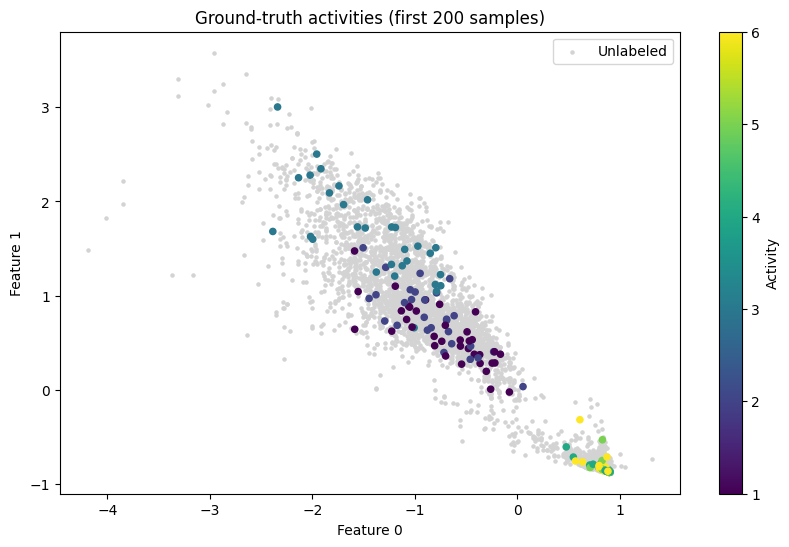

In [19]:
# Ground-truth visualization for labeled samples
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='lightgrey', s=5, label='Unlabeled')
scatter = plt.scatter(X_scaled[:200, 0], X_scaled[:200, 1], c=y_train, cmap='viridis', s=20)
plt.colorbar(scatter, label='Activity')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Ground-truth activities (first 200 samples)')
plt.legend()
plt.show()

### Visualize your groups

Plot a scatter plot of two features of your choice for all samples, coloring them by their cluster.

Do your cluster seem to correspond to the true activity clusters?

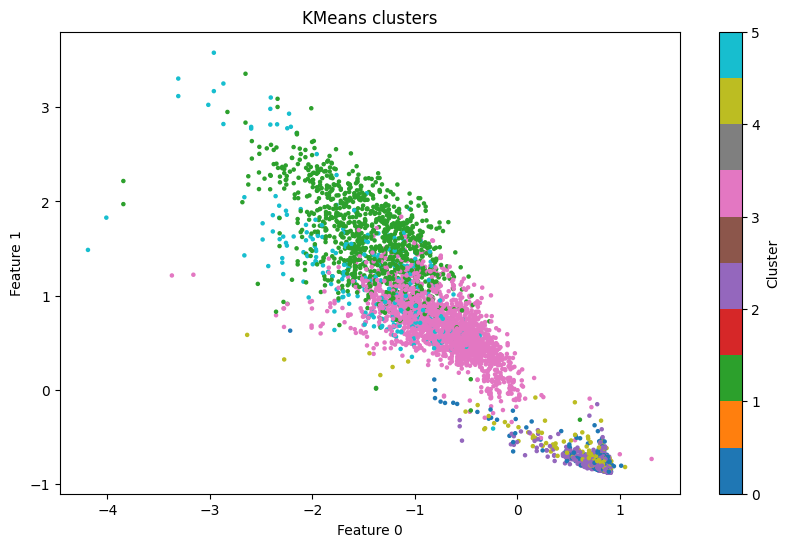

In [20]:
# Visualize clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('KMeans clusters')
plt.show()

Print the size of each cluster. Does it seem balanced? What does it mean?

In [21]:
unique_clusters, cluster_counts = np.unique(labels, return_counts=True)
for c, n in zip(unique_clusters, cluster_counts):
    print(f"Cluster {c}: {n} samples")

Cluster 0: 686 samples
Cluster 1: 1037 samples
Cluster 2: 2603 samples
Cluster 3: 1980 samples
Cluster 4: 755 samples
Cluster 5: 291 samples


### Performance metrics

#### Confusion matrix

We can evaluate the clusters by checking if they can be mapped into activities for the labeled samples. One way to inspect this mapping is through the confusion matrix. 

Calculate and print the confusion matrix for your clustering labels and the ground truth for the samples that are labeled.

Interpret the result by analyzing which types of activities each cluster contains. Note that if the matrix element $C_{i,j} = 8$, it means your model called 8 samples of category $j$ as being $i$.

In [22]:
cm = confusion_matrix(y_train.astype(int), labels[:200])
print("Confusion matrix (rows=true activity, cols=cluster):")
print(cm)

Confusion matrix (rows=true activity, cols=cluster):
[[ 0  0  0  0  0  0  0]
 [ 0  3  0 32  0  1  0]
 [ 0  4  0 23  0  1  0]
 [ 0 16  0  7  0  7  0]
 [ 0  0 31  0  0  0  0]
 [ 0  0 44  0  0  0  0]
 [18  1  0  0 12  0  0]]


#### Adjusted Rand Score (ARS)

A common metric to evaluate if a clustering maps into some grouping is the adjusted Rand score. The Rand Index computes a similarity measure between two clusterings by considering all pairs of samples and counting pairs that are assigned in the same or different clusters in the predicted and true clusterings. The raw RI score is then adjusted for chance into the adjusted score.

Calculate the ARS for the labeled samples, using `adjusted_rand_score()` in `sklearn`. This is the performance metric that will be used to test your predictions in the test set. A score over 0.5 is a good target. Can you do better?

In [23]:
ars = adjusted_rand_score(y_train.astype(int), labels[:200])
print(f"Adjusted Rand Score (with features): {ars:.4f}")

Adjusted Rand Score (with features): 0.4963


For comparison, run your clustering model directly on the raw time-series data `X_train` (without feature extraction and preprocessing) and check the performance.

In [24]:
# Clustering on raw time-series for comparison
scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_train)
kmeans_raw = KMeans(n_clusters=6, random_state=42, n_init=20, max_iter=500)
kmeans_raw.fit(X_raw_scaled)
ars_raw = adjusted_rand_score(y_train.astype(int), kmeans_raw.labels_[:200])
print(f"Adjusted Rand Score (raw data): {ars_raw:.4f}")

Adjusted Rand Score (raw data): 0.3135


### Predict test set groups

Save the clustering labels for all samples in the variable `cluster_labels`. It will be evaluated against the ground-truth using the adjusted rand score.

In [25]:
cluster_labels = labels